# Fuel Cost-Shock Forecaster — Multi-Agent Setup

Adapted from the [`energy_oil_forecasting`](../energy_oil_forecasting/) (WTI) reference implementation. Full objectives: [`../../fuel-cost-shock-forecaster/Fuel_Cost_Shock_Forecaster_Objectives_and_Requirements.md`](../../fuel-cost-shock-forecaster/Fuel_Cost_Shock_Forecaster_Objectives_and_Requirements.md).

**Bootcamp convention: everything lives in this notebook.** No `data.py` / `tasks.py` / `news_agent/` / `forecaster_agent/` package modules — the Commodity-Data ingestion, the Geopolitical/News Agent, the Forecaster Agent, and all predictor versions are defined inline so the whole pipeline runs top-to-bottom.

**Architecture: 3 agents, no Adjudicator.**

| Agent | Section | Role |
|---|---|---|
| Commodity-Data Agent | §2 | `DataService`: yfinance (HO=F, CL=F, DX-Y.NYB) + FRED (CAD/USD FX) + EIA (crude/jet-fuel spot) + derived shock-event series |
| Geopolitical/News Agent | §3 | `ContextRetrievalConfig` sub-agent (`search_web`) with temporal-leakage verifier |
| Forecaster Agent | §4 | `AgentConfig`; three calibration variants — V1, V2, V3 |

**Three forecaster versions (§4 defines predictors; §5 runs them live; §7 backtests all three apples-to-apples):**

| Version | Calibration strategy | Prompt builder | Post-processing |
|---|---|---|---|
| **V1** | Open-ended guidance (base rate ~10-15%) | `EnhancedFuelPromptBuilder` (WTI + USD covariates) | None |
| **V2** | Explicit momentum-anchored rules (hard caps per signal tier) | `EnhancedFuelPromptBuilder` | None |
| **V3** | Conservative prompt (always start at 15%) | `EnhancedFuelPromptBuilder` | Mechanical shrink: `p_out = p_raw × 0.6 + 0.15 × 0.4` |

**Targets:**
- **Primary (binary):** P(HO=F rises > 10% over the next 21 trading days) — the cost-shock event.
- **Secondary (continuous):** HO=F point forecast at 5/10/21 trading days.

**Jet-fuel proxy:** NY Harbor ULSD / Heating Oil (`HO=F`) — standard middle-distillate proxy (no liquid public jet-fuel futures contract exists).

**Evaluation:** Brier score (primary) + log-loss (secondary) + bootstrap 95% CIs + win-rate vs baseline. Section §7 is the authoritative apples-to-apples comparison.


In [1]:
import json
import os
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display  # noqa: A004

from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters.base import BaseAdapter
from aieng.forecasting.data.adapters.fred import FREDAdapter
from aieng.forecasting.data.adapters.yfinance import YFinanceDailyAdapter
from aieng.forecasting.data.context import ForecastContext
from aieng.forecasting.evaluation.backtest import compute_brier_score
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods.agentic import (
    AgentPredictor,
    ContinuousAgentForecastOutput,
    DiscreteAgentForecastOutput,
)
from aieng.forecasting.methods.agentic.agent_factory import AgentConfig, ContextRetrievalConfig
from aieng.forecasting.models import ADVANCED_MODEL, LITE_MODEL
from dotenv import load_dotenv
from pydantic import BaseModel


warnings.filterwarnings("ignore")
load_dotenv()

# ── Model selection ──────────────────────────────────────────────────────────────────────────
AGENT_MODEL = LITE_MODEL
SEARCH_MODEL = LITE_MODEL
VERIFIER_MODEL = ADVANCED_MODEL

# ── Cost-shock target definition ──────────────────────────────────────────────────
SHOCK_THRESHOLD_PCT = 0.10
SHOCK_HORIZON_DAYS = 21  # ~1 trading month
TRAJECTORY_HORIZONS = [5, 10, 21]


def naive_utc_now() -> datetime:
    """Timezone-naive current UTC time (DataService / CutoffEnforcer require this)."""
    return datetime.now(tz=timezone.utc).replace(tzinfo=None)


def repo_data_dir() -> Path:
    """Return ``data/`` at the repository root (walk up from CWD if needed)."""
    cwd = Path.cwd().resolve()
    root = cwd
    while not (root / "pyproject.toml").exists():
        if root.parent == root:
            return cwd / "data"
        root = root.parent
    data_dir = root / "data"
    data_dir.mkdir(exist_ok=True)
    return data_dir


DATA_DIR = repo_data_dir()
print(f"Data cache root: {DATA_DIR}")

Data cache root: /home/coder/agentic-forecasting/implementations/data


---
## 1. Commodity-Data Agent

Realised as a `DataService` registration layer, not a separate LLM call — every reference implementation in this repo (WTI, BoC, S&P 500) treats quantitative time-series data as a structured prompt payload, not something an agent fetches or summarizes. `FuelMultitaskPromptBuilder` (§4) builds the payload from the service below, fulfilling this agent's role structurally.

**Data sources (doc §6):**

| Source | Series | Key required? |
|---|---|---|
| yfinance | jet-fuel proxy `HO=F`, WTI `CL=F`, USD index `DX-Y.NYB` | No |
| FRED | `DEXCAUS` (CAD/USD spot FX) — stands in for the doc's "Bank of Canada Valet API" (no Valet adapter exists in this repo; FRED covers the same signal) | `FRED_API_KEY` (set) |
| EIA Open Data | `RWTC` (WTI Cushing spot), `EER_EPJK_PF4_RGC_DPG` (US Gulf Coast jet-fuel spot) — verified against `eia-api-swagger.yaml` | `EIA_API_KEY` (set) |

EIA inventory/stocks series (`petroleum/stoc/...`) are **not yet added** — not verified against the swagger file yet. GDELT 2.0 (doc's alternative news feed) is not evaluated.

In [2]:
# ── EIA Open Data adapter (API v2) ────────────────────────────────────────────────
# Not a pre-existing aieng adapter -- built here against eia-api-swagger.yaml
# (route: /v2/petroleum/{route1}/{route2}/data, params: api_key, frequency,
# data[], facets[series][], sort[0][column]/[direction], offset, length).
# Mirrors FREDAdapter's cache-to-parquet convention.

EIA_BASE_URL = "https://api.eia.gov/v2"
EIA_PAGE_LENGTH = 5000  # API max rows per request


class EIAAdapter(BaseAdapter):
    """Adapter for a single EIA Open Data API v2 petroleum series, with disk cache.

    Parameters
    ----------
    route1, route2 : str
        EIA route segments, e.g. ``"pri", "spt"`` for spot prices.
    series_id : str
        EIA facet series id, e.g. ``"RWTC"`` or ``"EER_EPJK_PF4_RGC_DPG"``.
    frequency : str
        EIA frequency string (``"daily"``, ``"weekly"``, ...).
    api_key : str or None
        EIA API key. Defaults to the ``EIA_API_KEY`` environment variable.
    cache_dir : Path or None
        Parquet cache directory. Defaults to ``data/eia``.
    refresh : bool
        Force a network re-fetch even if a cache file exists.
    """

    def __init__(
        self,
        route1: str,
        route2: str,
        series_id: str,
        *,
        frequency: str = "daily",
        api_key: str | None = None,
        cache_dir: Path | None = None,
        refresh: bool = False,
    ) -> None:
        self._route1 = route1
        self._route2 = route2
        self._series_id = series_id
        self._frequency = frequency
        self._api_key = api_key or os.environ.get("EIA_API_KEY")
        self._cache_dir = cache_dir if cache_dir is not None else DATA_DIR / "eia"
        self._refresh = refresh

    @property
    def cache_path(self) -> Path:
        return self._cache_dir / f"{self._series_id}.parquet"

    def fetch(self) -> pd.DataFrame:
        if self.cache_path.exists() and not self._refresh:
            df = pd.read_parquet(self.cache_path)
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["released_at"] = pd.to_datetime(df["released_at"])
            return df

        df = self._fetch_from_api()
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(self.cache_path, index=False)
        return df

    def _fetch_from_api(self) -> pd.DataFrame:
        if not self._api_key:
            raise ValueError(
                "EIA API key not provided. Set the EIA_API_KEY environment variable "
                "or pass api_key= to EIAAdapter."
            )

        url = f"{EIA_BASE_URL}/petroleum/{self._route1}/{self._route2}/data/"
        rows: list[dict] = []
        offset = 0
        while True:
            params = {
                "api_key": self._api_key,
                "frequency": self._frequency,
                "data[0]": "value",
                "facets[series][]": self._series_id,
                "sort[0][column]": "period",
                "sort[0][direction]": "asc",
                "offset": offset,
                "length": EIA_PAGE_LENGTH,
            }
            resp = requests.get(url, params=params, timeout=30)
            resp.raise_for_status()
            payload = resp.json()["response"]
            page = payload["data"]
            rows.extend(page)
            if len(page) < EIA_PAGE_LENGTH:
                break
            offset += EIA_PAGE_LENGTH

        if not rows:
            raise RuntimeError(f"EIA series '{self._series_id}' returned no data.")

        df = pd.DataFrame(rows)
        df["timestamp"] = pd.to_datetime(df["period"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["value"]).sort_values("timestamp").reset_index(drop=True)
        df["released_at"] = df["timestamp"]  # EIA doesn't expose vintage dates via this route
        return df[["timestamp", "value", "released_at"]]

    def __repr__(self) -> str:
        return f"EIAAdapter(route={self._route1}/{self._route2}, series_id={self._series_id!r})"


print("EIAAdapter defined.")

EIAAdapter defined.


In [3]:
# ── Canonical series IDs ───────────────────────────────────────────────────────────────
FUEL_SERIES_ID = "jet_fuel_proxy_price"  # yfinance HO=F -- primary target
WTI_SERIES_ID = "wti_crude_oil_price"  # yfinance CL=F -- covariate
USD_INDEX_SERIES_ID = "usd_index_price"  # yfinance DX-Y.NYB -- covariate
CAD_USD_FX_SERIES_ID = "cad_usd_fx_rate"  # FRED DEXCAUS -- covariate
EIA_WTI_SPOT_SERIES_ID = "eia_wti_spot_price"  # EIA RWTC -- covariate
EIA_JET_FUEL_SPOT_SERIES_ID = "eia_jet_fuel_spot_price"  # EIA EER_EPJK_PF4_RGC_DPG -- covariate
SHOCK_EVENT_SERIES_ID = "fuel_cost_shock_event_21d"  # derived binary series -- primary task target

_FUEL_TICKER = "HO=F"
_WTI_TICKER = "CL=F"
_USD_INDEX_TICKER = "DX-Y.NYB"
_HISTORY_START = "2004-01-01"


def derive_shock_event_series(
    price_df: pd.DataFrame,
    *,
    horizon_days: int = SHOCK_HORIZON_DAYS,
    threshold_pct: float = SHOCK_THRESHOLD_PCT,
) -> pd.DataFrame:
    """Derive the rolling binary cost-shock event series from a daily price series.

    For each row at date ``t``, looks ``horizon_days`` trading rows ahead to date
    ``t+h`` and sets ``value = 1.0`` if ``price[t+h] / price[t] - 1 > threshold_pct``,
    else ``0.0``. ``released_at`` is set to ``t+h`` -- the event is only knowable
    once the horizon has resolved -- so ``CutoffEnforcer`` correctly hides it from
    any origin before that date.
    """
    df = price_df.sort_values("timestamp").reset_index(drop=True)
    timestamps = pd.to_datetime(df["timestamp"])
    values = df["value"].astype(float)

    n = len(df)
    if n <= horizon_days:
        return pd.DataFrame(columns=["timestamp", "value", "released_at"])

    origin = values.iloc[: n - horizon_days].reset_index(drop=True)
    resolved = values.iloc[horizon_days:].reset_index(drop=True)
    pct_change = resolved / origin - 1.0

    return pd.DataFrame(
        {
            "timestamp": timestamps.iloc[: n - horizon_days].reset_index(drop=True),
            "value": (pct_change > threshold_pct).astype(float),
            "released_at": timestamps.iloc[horizon_days:].reset_index(drop=True),
        }
    )


class FuelShockEventAdapter(BaseAdapter):
    """Adapter producing the derived rolling cost-shock event series.

    Wraps the underlying price adapter and recomputes the derived series at
    fetch time, so it always reflects the freshest cached price data.
    """

    def __init__(self, price_adapter: BaseAdapter, *, horizon_days: int = SHOCK_HORIZON_DAYS, threshold_pct: float = SHOCK_THRESHOLD_PCT) -> None:
        self._price_adapter = price_adapter
        self._horizon_days = horizon_days
        self._threshold_pct = threshold_pct

    def fetch(self) -> pd.DataFrame:
        price_df = self._price_adapter.fetch()
        return derive_shock_event_series(price_df, horizon_days=self._horizon_days, threshold_pct=self._threshold_pct)


def build_fuel_service(cache_dir: Path | None = None) -> DataService:
    """Return a :class:`DataService` with the fuel cost-shock series registered.

    Registers the jet-fuel proxy target, the derived shock-event series, and
    the WTI / USD-index / CAD-USD-FX / EIA-spot covariates.
    """
    resolved_cache_dir = cache_dir if cache_dir is not None else DATA_DIR / "yfinance"
    svc = DataService()

    fuel_adapter = YFinanceDailyAdapter(ticker=_FUEL_TICKER, start=_HISTORY_START, cache_dir=resolved_cache_dir)
    svc.register(
        FUEL_SERIES_ID,
        fuel_adapter,
        SeriesMetadata(
            series_id=FUEL_SERIES_ID,
            description="NY Harbor ULSD / Heating Oil front-month futures adjusted close (Yahoo Finance HO=F) -- jet-fuel proxy.",
            source="yfinance",
            units="USD/gal",
            frequency="B",
        ),
    )

    svc.register(
        SHOCK_EVENT_SERIES_ID,
        FuelShockEventAdapter(fuel_adapter),
        SeriesMetadata(
            series_id=SHOCK_EVENT_SERIES_ID,
            description=(
                f"Cost-shock indicator: 1.0 if {FUEL_SERIES_ID} rises more than "
                f"{SHOCK_THRESHOLD_PCT:.0%} over the following {SHOCK_HORIZON_DAYS} business days, else 0.0."
            ),
            source=f"Derived ({FUEL_SERIES_ID})",
            units="0/1 event indicator",
            frequency="B",
        ),
    )

    svc.register(
        WTI_SERIES_ID,
        YFinanceDailyAdapter(ticker=_WTI_TICKER, start=_HISTORY_START, cache_dir=resolved_cache_dir),
        SeriesMetadata(
            series_id=WTI_SERIES_ID,
            description="WTI Crude Oil front-month futures adjusted close (Yahoo Finance CL=F)",
            source="yfinance",
            units="USD/bbl",
            frequency="B",
        ),
    )

    svc.register(
        USD_INDEX_SERIES_ID,
        YFinanceDailyAdapter(ticker=_USD_INDEX_TICKER, field="Adj Close", start=_HISTORY_START, cache_dir=resolved_cache_dir),
        SeriesMetadata(
            series_id=USD_INDEX_SERIES_ID,
            description="US Dollar Index close level (Yahoo Finance DX-Y.NYB)",
            source="yfinance",
            units="index-level",
            frequency="B",
        ),
    )

    try:
        svc.register(
            CAD_USD_FX_SERIES_ID,
            FREDAdapter("DEXCAUS", cache_dir=DATA_DIR / "fred"),
            SeriesMetadata(
                series_id=CAD_USD_FX_SERIES_ID,
                description="Canadian Dollars to U.S. Dollar spot exchange rate (FRED DEXCAUS)",
                source="FRED (DEXCAUS)",
                units="CAD per USD",
                frequency="B",
            ),
        )
    except (RuntimeError, ValueError) as exc:
        warnings.warn(f"Skipping CAD/USD FX (FRED): {exc}", stacklevel=2)

    try:
        svc.register(
            EIA_WTI_SPOT_SERIES_ID,
            EIAAdapter("pri", "spt", "RWTC"),
            SeriesMetadata(
                series_id=EIA_WTI_SPOT_SERIES_ID,
                description="Cushing, OK WTI spot price FOB (EIA RWTC)",
                source="EIA Open Data (petroleum/pri/spt, RWTC)",
                units="USD/bbl",
                frequency="B",
            ),
        )
        svc.register(
            EIA_JET_FUEL_SPOT_SERIES_ID,
            EIAAdapter("pri", "spt", "EER_EPJK_PF4_RGC_DPG"),
            SeriesMetadata(
                series_id=EIA_JET_FUEL_SPOT_SERIES_ID,
                description="US Gulf Coast kerosene-type jet-fuel spot price FOB (EIA EER_EPJK_PF4_RGC_DPG)",
                source="EIA Open Data (petroleum/pri/spt, EER_EPJK_PF4_RGC_DPG)",
                units="USD/gal",
                frequency="B",
            ),
        )
    except (RuntimeError, ValueError) as exc:
        warnings.warn(f"Skipping EIA spot-price covariates: {exc}", stacklevel=2)

    return svc


print("build_fuel_service() defined.")

build_fuel_service() defined.


In [4]:
# Build the service and preview the price history through today.
data_service = build_fuel_service()
ctx0 = data_service.context(as_of=naive_utc_now())
fuel_df = ctx0.get_series(FUEL_SERIES_ID)
print(f"Jet-fuel proxy (HO=F) history through {pd.Timestamp(fuel_df['timestamp'].max()).date()}, {len(fuel_df)} rows")
print(f"Registered series: {list(data_service.series_ids)}")

Jet-fuel proxy (HO=F) history through 2026-10-04, 5722 rows
Registered series: ['cad_usd_fx_rate', 'eia_jet_fuel_spot_price', 'eia_wti_spot_price', 'fuel_cost_shock_event_21d', 'jet_fuel_proxy_price', 'usd_index_price', 'wti_crude_oil_price']


---
## 2. Geopolitical / News Agent

A `ContextRetrievalConfig` sub-agent (the same primitive `energy_oil_forecasting` uses for its news-grounded configs) with a temporal-leakage verifier, wired into the Forecaster Agent below as the `search_web` tool. GDELT 2.0 (doc's alternative feed) is not wired up here.

In [5]:
FUEL_NEWS_INSTRUCTION = """
You are a jet-fuel and crude-oil market intelligence specialist with access to web search.

Search for information relevant to the query and return a concise structured markdown summary (3-5 paragraphs) covering relevant aspects of:
- Crude oil (WTI/Brent) and refined-products (jet fuel / heating oil / diesel) price level and recent trend
- OPEC+ production decisions and supply outlook
- Geopolitical risks in the Persian Gulf, Middle East, Strait of Hormuz, and other key shipping lanes affecting crude and product tanker flows
- US EIA policy releases, Strategic Petroleum Reserve actions, and inventory data surprises
- Refinery outages or disruptions affecting jet fuel / distillate supply
- Notable analyst forecasts or unusual price-target revisions for crude or refined products

Ground your summary in the search results you actually retrieve. When a cutoff date is specified, do not report or speculate about events that occurred after that date.

Before finalizing your summary, reason step by step: (1) for each candidate fact, judge its actual recency from the substance of the result itself, never from a source's claimed publish date or byline timestamp -- those are frequently stale or updated after original publication; (2) discard anything you cannot confidently place before the cutoff date; (3) only then write your summary. Do not supplement the search results with your own background/training knowledge -- if the results are insufficient, say so explicitly rather than filling gaps from memory.
""".strip()

FUEL_CONTEXT_RETRIEVAL_SUPPLEMENT = """

## Context retrieval

Call ``search_web`` to gather market intelligence BEFORE producing forecasts.

Call ``search_web`` with ``query`` and ``cutoff_date`` (set to the ``as_of`` date from the payload). The ``cutoff_date`` MUST always equal ``as_of`` -- this is the temporal fence that prevents post-origin information from contaminating historical backtests.

If ``search_web`` returns a result beginning with ``[SEARCH_VERIFICATION_FAILED]``, treat it as no verified news context for that query. Do not use your own background knowledge to fill the gap or speculate about what the news might have said -- proceed with price-history and other available signals only, and note the gap in your rationale.

Recommended queries (call ``search_web`` once per topic):
- ``search_web(query="crude oil and jet fuel price trend and OPEC+ supply decisions", cutoff_date=<as_of>)``
- ``search_web(query="Persian Gulf geopolitical risk shipping lane disruptions", cutoff_date=<as_of>)``
- ``search_web(query="US EIA policy releases and Strategic Petroleum Reserve actions", cutoff_date=<as_of>)``
- ``search_web(query="refinery outages affecting jet fuel and distillate supply", cutoff_date=<as_of>)``
"""


def build_fuel_context_retrieval_config(
    search_model: str = SEARCH_MODEL,
    verifier_model: str = VERIFIER_MODEL,
    verifier_max_attempts: int = 3,
    verifier_confidence_threshold: int = 8,
) -> ContextRetrievalConfig:
    """Build the Geopolitical/News Agent's :class:`ContextRetrievalConfig`."""
    return ContextRetrievalConfig(
        enabled=True,
        instruction=FUEL_NEWS_INSTRUCTION,
        search_model=search_model,
        verifier_model=verifier_model,
        verifier_max_attempts=verifier_max_attempts,
        verifier_confidence_threshold=verifier_confidence_threshold,
    )


print("News Agent instruction + factory defined.")

News Agent instruction + factory defined.


---
## 3. Forecaster Agent — Shared Config + All Three Predictor Versions

"One agent, three calibration strategies": a single `AgentConfig` / `AgentPredictor` class, with the calibration ask living in each version's `task_spec`.

All three versions use **`EnhancedFuelPromptBuilder`**, which sends the agent:
- `momentum_signals` — HO=F 5-day and 21-day returns, 21-day rolling volatility
- `covariate_summary` — WTI crude and USD index 21-day returns
- `target_history_csv` — compressed HO=F daily close history

**V3** additionally wraps its `AgentPredictor` in `ShrinkingAgentPredictor`, which mechanically blends the raw LLM probability toward the historical base rate after every call:
```
p_out = p_raw × (1 − SHRINK_FACTOR) + BASE_RATE × SHRINK_FACTOR
```
This guarantees conservatism regardless of how the LLM interprets the prompt.


In [6]:
FUEL_FORECASTER_INSTRUCTION = """
## Role

You are an expert jet-fuel and crude-oil market analyst producing calibrated probability forecasts
to support airline hedging, budgeting, and financial risk decisions.

## Input fields

You will receive a JSON payload with these fields:
- `task_spec`: the exact question, calibration rules, and required JSON output schema
- `as_of`: the forecast origin date (your temporal cutoff — never use information after this date)
- `horizons`: integer horizon steps (business days ahead)
- `standard_quantiles`: quantile levels for continuous forecasts (when applicable)
- `origin_price_usd_gal`: HO=F (jet-fuel proxy) closing price on the origin date
- `momentum_signals`: pre-computed price returns over 5d and 21d windows, plus 21d rolling volatility
- `covariate_summary`: WTI crude and USD index 21d returns — key co-predictors of jet-fuel shocks
- `target_history_csv`: compressed HO=F daily close history (recent 6 months daily, older weekly)

## How to use the signals

1. Read `momentum_signals.ret_21d` and `covariate_summary.wti_crude_ret_21d` BEFORE searching.
   These determine your starting anchor before qualitative adjustment.
2. Call `search_web` BEFORE producing estimates — it is your only source of qualitative intelligence
   (OPEC+ policy, geopolitical supply risk, EIA inventory releases, refinery outages).
3. WTI crude leads jet fuel by 1-3 days. Strong USD tends to suppress oil prices.
4. Never supplement search results with your own training-time knowledge about post-`as_of` events.

## Output contract

Execute the task in `task_spec` precisely.
If a `set_model_response` tool is available, call it with your complete JSON as `json_response`.
Otherwise return the JSON directly as plain text with no preamble.
""".strip()


def build_fuel_forecaster_config(
    model: str = AGENT_MODEL,
    search_model: str = SEARCH_MODEL,
    verifier_model: str = VERIFIER_MODEL,
) -> AgentConfig:
    """Build the Forecaster Agent's :class:`AgentConfig`, wiring in the News Agent."""
    return AgentConfig(
        name="fuel_shock_forecaster",
        model=model,
        instruction=FUEL_FORECASTER_INSTRUCTION,
        context_retrieval=build_fuel_context_retrieval_config(
            search_model=search_model, verifier_model=verifier_model
        ),
    )


def _compress_history(df: pd.DataFrame) -> str:
    """Compress daily price history: recent 6 months daily, older weekly averages."""
    frame = df.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    cutoff = frame["timestamp"].max() - pd.DateOffset(months=6)
    recent = frame[frame["timestamp"] >= cutoff]
    old = frame[frame["timestamp"] < cutoff]
    rows: list[str] = ["date,close"]
    if not old.empty:
        weekly = old.set_index("timestamp")["value"].resample("W").mean().dropna()
        rows.extend(f"{date.date()},{val:.3f}" for date, val in weekly.items())
    rows.extend(
        f"{row['timestamp'].date()},{row['value']:.3f}" for _, row in recent.iterrows()
    )
    return "\n".join(rows)


class FuelMultitaskPromptBuilder(BaseModel):
    """Minimal prompt builder used by the trajectory task (no momentum covariates needed)."""

    task_spec: str
    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context: ForecastContext) -> str:
        df = context.get_series(task.target_series_id)
        last_row = df.iloc[-1]
        payload = {
            "task": task.task_id,
            "task_spec": self.task_spec,
            "as_of": str(context.as_of)[:10],
            "horizons": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "origin_price_usd_gal": float(last_row["value"]),
            "target_history_csv": _compress_history(df),
        }
        return json.dumps(payload, indent=2)


# ── Backtest compatibility patch ───────────────────────────────────────────────────
# Binary shock tasks are scored against SHOCK_EVENT_SERIES_ID, but the agent must
# receive HO=F price history (not the derived 0/1 series) as input.
_original_fmpb_call = FuelMultitaskPromptBuilder.__call__


def _fmpb_call_patched(self, *, task: ForecastingTask, context: ForecastContext) -> str:
    if task.payload_type == "binary" and task.target_series_id == SHOCK_EVENT_SERIES_ID:
        price_task = task.model_copy(update={"target_series_id": FUEL_SERIES_ID})
        return _original_fmpb_call(self, task=price_task, context=context)
    return _original_fmpb_call(self, task=task, context=context)


FuelMultitaskPromptBuilder.__call__ = _fmpb_call_patched

# ── Task specs ─────────────────────────────────────────────────────────────────────
TASK_SHOCK_SPEC = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {SHOCK_THRESHOLD_PCT:.0%} HIGHER than today's price at the end of\n"
    f"{SHOCK_HORIZON_DAYS} trading days (the cost-shock event).\n\n"
    "This is a directional upside question only.\n\n"
    "Calibration guidance:\n"
    "  - No unusual upside catalyst       -> base rate ~10-15%\n"
    "  - Escalating unconfirmed risk      -> 20-40%\n"
    "  - Confirmed supply disruption      -> 60-85%\n\n"
    "Use `key_signals` to name the specific drivers (OPEC+ decisions, shipping-lane\n"
    "risk, inventory levels, refinery outages, macro demand) behind your estimate.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

TASK_SHOCK_SPEC_V2 = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {SHOCK_THRESHOLD_PCT:.0%} HIGHER than today's price at the end of\n"
    f"{SHOCK_HORIZON_DAYS} trading days (the cost-shock event).\n\n"
    "This is a directional upside question only.\n\n"
    "CALIBRATION RULES — follow these strictly:\n"
    "  1. Start from the base rate: historically ~15% of 21-day windows see a >10% rise.\n"
    "  2. Check momentum_signals.ret_21d:\n"
    "     - ret_21d < -5%  → adjust DOWN toward 8-12%\n"
    "     - ret_21d -5% to +5% → stay near base rate 12-18%\n"
    "     - ret_21d > +5%  → adjust UP toward 20-35%\n"
    "  3. Only go above 40% for a CONFIRMED supply disruption (not rumour).\n"
    "  4. Only go above 60% if the disruption is actively cutting supply RIGHT NOW.\n"
    "  5. Geopolitical tension alone (without confirmed supply impact) = max 30%.\n\n"
    "Use `key_signals` to name the specific drivers behind your estimate.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

TASK_SHOCK_SPEC_V3 = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {SHOCK_THRESHOLD_PCT:.0%} HIGHER than today's price at the end of\n"
    f"{SHOCK_HORIZON_DAYS} trading days (the cost-shock event).\n\n"
    "CRITICAL CALIBRATION — the historical base rate is 15%. Most months have NO shock.\n\n"
    "RULES:\n"
    "  - Start at 15% always.\n"
    "  - Only move above 25% if momentum_signals.ret_21d > +5% AND a confirmed supply event exists.\n"
    "  - Only move above 40% if there is an ACTIVE, CONFIRMED supply disruption RIGHT NOW.\n"
    "  - Geopolitical tension, rumours, or risk premiums alone = stay at 15-20%.\n"
    "  - When in doubt, stay closer to 15% than to 50%.\n\n"
    "Use `key_signals` to name the specific drivers behind your estimate.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

TASK_TRAJECTORY_SPEC = (
    "Forecast the jet-fuel proxy price at each horizon listed in the payload "
    "(`horizons`, business days ahead).\n\n"
    "Rules:\n"
    "  - Produce one forecast for each horizon in `horizons`.\n"
    "  - Use exactly the quantile levels from `standard_quantiles` -- no additions, no omissions.\n"
    "  - `point_forecast` must exactly equal the 0.50 quantile value.\n"
    "  - Quantile values must be strictly non-decreasing as quantile levels increase.\n"
    "  - Document your reasoning in the `rationale` fields.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + ContinuousAgentForecastOutput.prompt_schema_json()
)

forecaster_config = build_fuel_forecaster_config()
print(f"Forecaster Agent config: {forecaster_config.name} (model={forecaster_config.model})")
print("Task specs defined: TASK_SHOCK_SPEC (V1), TASK_SHOCK_SPEC_V2, TASK_SHOCK_SPEC_V3, TASK_TRAJECTORY_SPEC")


Forecaster Agent config: fuel_shock_forecaster (model=gemini-3.1-flash-lite-preview)
Task specs defined: TASK_SHOCK_SPEC (V1), TASK_SHOCK_SPEC_V2, TASK_SHOCK_SPEC_V3, TASK_TRAJECTORY_SPEC


In [7]:
class EnhancedFuelPromptBuilder(BaseModel):
    """Prompt builder for all three shock-forecast versions.

    Adds pre-computed momentum signals (HO=F 5d/21d returns, 21d vol) and
    covariate summary (WTI and USD index 21d returns) to the agent payload,
    giving it the two strongest quantitative co-predictors of jet-fuel shocks.
    Falls back gracefully if a covariate series is unavailable.
    """

    task_spec: str
    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context: ForecastContext) -> str:
        # Always feed HO=F price history — even for the shock-event task
        if task.target_series_id == SHOCK_EVENT_SERIES_ID:
            df = context.get_series(FUEL_SERIES_ID)
        else:
            df = context.get_series(task.target_series_id)

        last_row = df.iloc[-1]
        prices = df["value"].astype(float)

        ret_5d  = float(prices.pct_change(5).iloc[-1])
        ret_21d = float(prices.pct_change(21).iloc[-1])
        vol_21d = float(prices.pct_change().rolling(21).std().iloc[-1])

        try:
            wti_df = context.get_series(WTI_SERIES_ID)
            wti_ret_21d = float(wti_df["value"].astype(float).pct_change(21).iloc[-1])
            wti_summary = f"{wti_ret_21d:+.1%} over 21 days"
        except Exception:
            wti_summary = "unavailable"

        try:
            usd_df = context.get_series(USD_INDEX_SERIES_ID)
            usd_ret_21d = float(usd_df["value"].astype(float).pct_change(21).iloc[-1])
            usd_summary = f"{usd_ret_21d:+.1%} over 21 days"
        except Exception:
            usd_summary = "unavailable"

        payload = {
            "task": task.task_id,
            "task_spec": self.task_spec,
            "as_of": str(context.as_of)[:10],
            "horizons": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "origin_price_usd_gal": float(last_row["value"]),
            "momentum_signals": {
                "ret_5d":       f"{ret_5d:+.2%}",
                "ret_21d":      f"{ret_21d:+.2%}",
                "volatility_21d": f"{vol_21d:.3f}",
                "note": "Positive ret_21d = upward momentum; high vol = wider shock distribution",
            },
            "covariate_summary": {
                "wti_crude_ret_21d": wti_summary,
                "usd_index_ret_21d": usd_summary,
                "note": "Strong USD suppresses oil prices; rising WTI leads jet fuel by 1-3 days",
            },
            "target_history_csv": _compress_history(df),
        }
        return json.dumps(payload, indent=2)


print("EnhancedFuelPromptBuilder defined.")


EnhancedFuelPromptBuilder defined.


In [8]:
BASE_RATE    = 0.15   # historical ~15% of 21-day windows see a >10% rise
SHRINK_FACTOR = 0.4   # blend 40% toward BASE_RATE after LLM call


class ShrinkingAgentPredictor:
    """Wraps an AgentPredictor and blends each predicted probability toward BASE_RATE.

    p_out = p_raw * (1 - shrink_factor) + base_rate * shrink_factor

    All attribute access not defined on this class is delegated to the wrapped inner
    predictor so that frameworks inspecting `.output_schema`, `.agent_config`, etc. work.
    """

    def __init__(
        self,
        inner: AgentPredictor,
        base_rate: float = BASE_RATE,
        shrink_factor: float = SHRINK_FACTOR,
    ) -> None:
        self._inner        = inner
        self._base_rate    = base_rate
        self._shrink_factor = shrink_factor
        self.predictor_id  = inner.predictor_id   # expose so cached_backtest can key cache

    def predict(self, task, context):
        predictions = self._inner.predict(task, context)
        shrunk = []
        for pred in predictions:
            raw     = pred.payload.probability
            blended = raw * (1 - self._shrink_factor) + self._base_rate * self._shrink_factor
            new_payload = pred.payload.model_copy(update={"probability": round(blended, 4)})
            shrunk.append(pred.model_copy(update={"payload": new_payload}))
        return shrunk

    def __getattr__(self, name):
        # Delegate any attribute not found here to the inner predictor
        return getattr(self._inner, name)

    def __repr__(self) -> str:
        return (
            f"ShrinkingAgentPredictor(inner={self._inner!r}, "
            f"base_rate={self._base_rate}, shrink_factor={self._shrink_factor})"
        )


# Print shrinkage effect table
print(f"ShrinkingAgentPredictor defined  (base_rate={BASE_RATE:.0%}, shrink_factor={SHRINK_FACTOR:.0%})")
print("Shrinkage effect on raw → blended probability:")
for raw in [0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75]:
    blended = raw * (1 - SHRINK_FACTOR) + BASE_RATE * SHRINK_FACTOR
    print(f"  raw {raw:.0%} → blended {blended:.0%}")


ShrinkingAgentPredictor defined  (base_rate=15%, shrink_factor=40%)
Shrinkage effect on raw → blended probability:
  raw 15% → blended 15%
  raw 20% → blended 18%
  raw 30% → blended 24%
  raw 40% → blended 30%
  raw 50% → blended 36%
  raw 60% → blended 42%
  raw 75% → blended 51%


In [9]:
# Build all three shock predictors and the trajectory predictor.
# V1 and V2 use AgentPredictor directly.
# V3 wraps AgentPredictor in ShrinkingAgentPredictor.

shock_predictor_v1 = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=EnhancedFuelPromptBuilder(task_spec=TASK_SHOCK_SPEC),
    output_schema=DiscreteAgentForecastOutput,
)

shock_predictor_v2 = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=EnhancedFuelPromptBuilder(task_spec=TASK_SHOCK_SPEC_V2),
    output_schema=DiscreteAgentForecastOutput,
)

shock_predictor_v3 = ShrinkingAgentPredictor(
    inner=AgentPredictor(
        agent_config=forecaster_config,
        prompt_builder=EnhancedFuelPromptBuilder(task_spec=TASK_SHOCK_SPEC_V3),
        output_schema=DiscreteAgentForecastOutput,
    )
)

trajectory_predictor = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=FuelMultitaskPromptBuilder(task_spec=TASK_TRAJECTORY_SPEC),
    output_schema=ContinuousAgentForecastOutput,
)

print(f"V1 predictor_id : {shock_predictor_v1.predictor_id}")
print(f"V2 predictor_id : {shock_predictor_v2.predictor_id}")
print(f"V3 predictor_id : {shock_predictor_v3.predictor_id}  (mechanically shrunk)")
print(f"Trajectory      : {trajectory_predictor.predictor_id}")


V1 predictor_id : agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete
V2 predictor_id : agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete
V3 predictor_id : agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete  (mechanically shrunk)
Trajectory      : agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_continuous


---
## 4. Live Pipeline — All Three Versions at Today's Origin

Runs V1, V2, and V3 at today's date (no historical temporal fence) and displays full rationale for each. Set `USE_CACHE_LIVE = True` to reuse cached results.


In [10]:
USE_CACHE_LIVE = False
SHOCK_CACHE_V1   = DATA_DIR / "fuel_shock_forecast_v1.json"
SHOCK_CACHE_V2   = DATA_DIR / "fuel_shock_forecast_v2.json"
SHOCK_CACHE_V3   = DATA_DIR / "fuel_shock_forecast_v3.json"
TRAJ_CACHE       = DATA_DIR / "fuel_trajectory_forecast.json"

shock_task = ForecastingTask(
    task_id="fuel_cost_shock_next_month",
    target_series_id=FUEL_SERIES_ID,
    horizons=[SHOCK_HORIZON_DAYS],
    frequency="B",
    payload_type="binary",
    description="Binary cost-shock (live)",
)

trajectory_task = ForecastingTask(
    task_id="fuel_trajectory_next_month",
    target_series_id=FUEL_SERIES_ID,
    horizons=list(TRAJECTORY_HORIZONS),
    frequency="B",
    description="Continuous trajectory (live)",
)

live_ctx = data_service.context(as_of=naive_utc_now())


def run_or_load(predictor, task, ctx, cache_path, use_cache=USE_CACHE_LIVE):
    """Run predictor or load from cache; always returns a model-dump dict."""
    if use_cache and cache_path.exists():
        with open(cache_path) as f:
            result = json.load(f)
        print(f"Loaded cached: {cache_path.name}")
        return result
    preds = predictor.predict(task, ctx)
    result = preds[0].model_dump(mode="json")
    with open(cache_path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"Saved: {cache_path.name}")
    return result


shock_result_v1 = run_or_load(shock_predictor_v1, shock_task, live_ctx, SHOCK_CACHE_V1)
shock_result_v2 = run_or_load(shock_predictor_v2, shock_task, live_ctx, SHOCK_CACHE_V2)
shock_result_v3 = run_or_load(shock_predictor_v3, shock_task, live_ctx, SHOCK_CACHE_V3)

# Trajectory
if USE_CACHE_LIVE and TRAJ_CACHE.exists():
    with open(TRAJ_CACHE) as f:
        traj_result = json.load(f)
    print(f"Loaded cached: {TRAJ_CACHE.name}")
else:
    traj_preds = trajectory_predictor.predict(trajectory_task, live_ctx)
    traj_result = [p.model_dump(mode="json") for p in traj_preds]
    with open(TRAJ_CACHE, "w") as f:
        json.dump(traj_result, f, indent=2)
    print(f"Saved: {TRAJ_CACHE.name}")


Saved: fuel_shock_forecast_v1.json
Saved: fuel_shock_forecast_v2.json
Saved: fuel_shock_forecast_v3.json
Saved: fuel_trajectory_forecast.json


In [11]:
def display_forecast(label, result):
    payload = result["payload"]
    display(Markdown(
        f"### {label}\n\n"
        f"**P(>{SHOCK_THRESHOLD_PCT:.0%} rise in {SHOCK_HORIZON_DAYS} trading days) "
        f"= {payload['probability']:.0%}**\n\n"
        f"- Direction bias : {payload.get('direction_bias', '?')}\n"
        f"- Confidence     : {payload.get('confidence', '?')}\n"
        f"- Key signals    : {', '.join(payload.get('key_signals', [])) or '—'}\n\n"
        f"> {payload.get('reasoning', '')}"
    ))


display_forecast("V1 — Open-ended spec + EnhancedPromptBuilder",              shock_result_v1)
display_forecast("V2 — Momentum-anchored calibration + EnhancedPromptBuilder", shock_result_v2)
display_forecast("V3 — Conservative prompt + mechanical shrink",               shock_result_v3)

# Trajectory
print("\n── Trajectory forecast (V1 prompt builder) ──")
for h, pred in zip(TRAJECTORY_HORIZONS, traj_result, strict=False):
    pt = pred["payload"]["point_forecast"]
    print(f"  h={h:2d}bd  point_forecast = ${pt:.3f}/gal")


### V1 — Open-ended spec + EnhancedPromptBuilder

**P(>10% rise in 21 trading days) = 35%**

- Direction bias : ?
- Confidence     : ?
- Key signals    : —

> 

### V2 — Momentum-anchored calibration + EnhancedPromptBuilder

**P(>10% rise in 21 trading days) = 45%**

- Direction bias : ?
- Confidence     : ?
- Key signals    : —

> 

### V3 — Conservative prompt + mechanical shrink

**P(>10% rise in 21 trading days) = 27%**

- Direction bias : ?
- Confidence     : ?
- Key signals    : —

> 


── Trajectory forecast (V1 prompt builder) ──
  h= 5bd  point_forecast = $4.545/gal
  h=10bd  point_forecast = $4.620/gal
  h=21bd  point_forecast = $4.780/gal


In [12]:
v1_p = shock_result_v1["payload"]
v2_p = shock_result_v2["payload"]
v3_p = shock_result_v3["payload"]

print("=" * 75)
print("LIVE FORECAST COMPARISON  (all versions, EnhancedFuelPromptBuilder)")
print("=" * 75)
print(f"{'':32} {'V1':>10} {'V2':>10} {'V3 (shrunk)':>14}")
print(f"{'Probability':32} "
      f"{v1_p['probability']:.0%}{'':6} "
      f"{v2_p['probability']:.0%}{'':6} "
      f"{v3_p['probability']:.0%}")
print(f"{'Direction bias':32} "
      f"{str(v1_p.get('direction_bias','?')):>10} "
      f"{str(v2_p.get('direction_bias','?')):>10} "
      f"{str(v3_p.get('direction_bias','?')):>14}")
print(f"{'Confidence':32} "
      f"{str(v1_p.get('confidence','?')):>10} "
      f"{str(v2_p.get('confidence','?')):>10} "
      f"{str(v3_p.get('confidence','?')):>14}")
print()
for lbl, p in [("V1", v1_p), ("V2", v2_p), ("V3", v3_p)]:
    sigs = p.get('key_signals', [])
    print(f"{lbl} key signals: {', '.join(sigs) if sigs else '—'}")


LIVE FORECAST COMPARISON  (all versions, EnhancedFuelPromptBuilder)
                                         V1         V2    V3 (shrunk)
Probability                      35%       45%       27%
Direction bias                            ?          ?              ?
Confidence                                ?          ?              ?

V1 key signals: —
V2 key signals: —
V3 key signals: —


---
## 5. Evaluation Framework

**Metrics:**
- **Brier score** (primary): `BS = (p − y)²`, lower is better. Range [0, 1]. A coin-flip predictor scores 0.25; a predictor always outputting the base rate scores `p_base × (1 − p_base)`.
- **Log-loss** (secondary): `LL = −[y·log(p) + (1−y)·log(1−p)]`, lower is better. Penalises overconfident wrong predictions more heavily than Brier.
- **Bootstrap 95% CI** on mean Brier: 10,000 resample iterations. Two versions are statistically distinguishable only if their CIs do not overlap.
- **Win-rate vs baseline**: fraction of origins where the agent Brier < baseline Brier.

**Baselines:**
- `HistoricalFrequencyPredictor` — outputs the unconditional historical shock frequency. Naive floor.
- `RollingFrequencyPredictor` — outputs the trailing 12-month shock frequency at each origin. Smarter baseline that adapts to regime shifts (e.g. post-COVID volatility, 2022 energy crisis).


In [13]:
import math
import yaml

from aieng.forecasting.evaluation import BacktestSpec, cached_backtest
from aieng.forecasting.evaluation.backtest import BacktestResult
from aieng.forecasting.methods import HistoricalFrequencyPredictor


# ── Calibration table ──────────────────────────────────────────────────────────
def shock_calibration_table(
    probabilities: list[float],
    outcomes: list[float],
    n_bins: int = 5,
) -> pd.DataFrame:
    """Bin predicted probabilities and compare to realised outcome frequency."""
    df = pd.DataFrame({"probability": probabilities, "outcome": outcomes}).dropna()
    if df.empty:
        return pd.DataFrame(columns=["bin", "mean_predicted", "mean_observed", "n"])
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    df["bin"] = pd.cut(df["probability"], bins=edges, include_lowest=True)
    grouped = df.groupby("bin", observed=True).agg(
        mean_predicted=("probability", "mean"),
        mean_observed=("outcome", "mean"),
        n=("outcome", "count"),
    )
    return grouped.reset_index()


# ── Log-loss ───────────────────────────────────────────────────────────────────
def log_loss_score(probabilities: list[float], outcomes: list[float], eps: float = 1e-7) -> float:
    """Mean log-loss over paired (probability, outcome) observations.

    Clips predictions to [eps, 1-eps] to avoid log(0).
    Lower is better.
    """
    total = 0.0
    n = 0
    for p, y in zip(probabilities, outcomes, strict=True):
        if y is None or p is None:
            continue
        p_clipped = max(eps, min(1 - eps, p))
        total += -(y * math.log(p_clipped) + (1 - y) * math.log(1 - p_clipped))
        n += 1
    return total / n if n > 0 else float("nan")


# ── Bootstrap Brier CI ────────────────────────────────────────────────────────
def bootstrap_brier_ci(
    scores: list[float],
    n_boot: int = 10_000,
    ci: float = 0.95,
    rng_seed: int = 42,
) -> tuple[float, float]:
    """Bootstrap (1-alpha) CI on mean Brier score via percentile method.

    Returns (lower, upper) confidence interval bounds.
    """
    rng = np.random.default_rng(rng_seed)
    arr = np.array(scores, dtype=float)
    boot_means = np.array([
        rng.choice(arr, size=len(arr), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = 1 - ci
    return float(np.percentile(boot_means, 100 * alpha / 2)), float(np.percentile(boot_means, 100 * (1 - alpha / 2)))


# ── Rolling-frequency baseline ────────────────────────────────────────────────
class RollingFrequencyPredictor:
    """Smarter baseline: trailing 12-month empirical shock frequency at each origin.

    Adapts to regime shifts (post-COVID volatility, 2022 energy crisis) unlike the flat
    HistoricalFrequencyPredictor.

    Implementation: delegates to HistoricalFrequencyPredictor.predict() to get a correctly
    structured Prediction object, then patches its probability in-place. This ensures the
    return type is always identical to what cached_backtest expects — no manual Prediction
    construction that could miss required fields (predictor_id, task_id, issued_at, etc.).
    """

    predictor_id  = "rolling_freq_12m"
    LOOKBACK_DAYS = 252  # ~12 calendar months of business days

    def __init__(self) -> None:
        self._hist = HistoricalFrequencyPredictor()

    def predict(self, task, context) -> list:
        # 1. Compute trailing 12-month shock frequency from data visible at this origin
        try:
            event_df = context.get_series(SHOCK_EVENT_SERIES_ID)
        except Exception:
            event_df = context.get_series(task.target_series_id)
        event_df = event_df.sort_values("timestamp")
        recent   = event_df.tail(self.LOOKBACK_DAYS)
        freq     = float(recent["value"].mean()) if len(recent) > 0 else BASE_RATE
        freq     = max(0.01, min(0.99, freq))

        # 2. Get a correctly-typed Prediction from HistoricalFrequencyPredictor
        preds = self._hist.predict(task, context)

        # 3. Patch probability on whatever payload object the library uses
        patched = []
        for pred in preds:
            payload = pred.payload
            # BinaryForecast / DiscretePayload: try .probability first, then p
            if hasattr(payload, "probability"):
                new_payload = payload.model_copy(update={"probability": round(freq, 4)})
            elif hasattr(payload, "p"):
                new_payload = payload.model_copy(update={"p": round(freq, 4)})
            else:
                new_payload = payload  # fallback: leave as-is
            patched.append(pred.model_copy(update={"payload": new_payload}))
        return patched


# ── resolved_outcome — defined ONCE here, used in §6 and §7 ──────────────────
def resolved_outcome(
    forecast_date,
    target_series_id: str = SHOCK_EVENT_SERIES_ID,
) -> float | None:
    """Return observed 0/1 shock outcome at forecast_date, or None if not yet resolved."""
    full_series = data_service.get_series(target_series_id, as_of=naive_utc_now())
    match = full_series[
        pd.to_datetime(full_series["timestamp"]) == pd.Timestamp(forecast_date)
    ]
    return float(match["value"].iloc[0]) if not match.empty else None


print("Evaluation helpers ready:")
print("  shock_calibration_table, log_loss_score, bootstrap_brier_ci")
print("  RollingFrequencyPredictor (rolling 12m baseline)")
print("  resolved_outcome (defined once — used throughout §6 and §7)")


Evaluation helpers ready:
  shock_calibration_table, log_loss_score, bootstrap_brier_ci
  RollingFrequencyPredictor (rolling 12m baseline)
  resolved_outcome (defined once — used throughout §6 and §7)


---
## 6. Historical Reference Backtest (V1 — original `FuelMultitaskPromptBuilder`)

This section runs the original V1 predictor — using `FuelMultitaskPromptBuilder` (no WTI/USD covariates) — against the 2-year backtest spec. Its purpose is to establish a **historical reference score** for comparison with the enhanced versions in §7.

> ⚠️ **Note:** §7 is the authoritative apples-to-apples comparison. All three versions there use `EnhancedFuelPromptBuilder` and run on the same shared backtest spec.

### Historical case study: February 3, 2025

Origin: **February 3, 2025**. Outcome resolved at **March 4, 2025** (21 trading days). Context: proposed 25% tariffs on Canada/Mexico, steady OPEC+ cuts, HO=F ~$2.40/gal. Competing mechanisms: tariffs could tighten refinery inputs (bullish) or weaken demand (bearish).


In [14]:
import matplotlib.pyplot as plt

SPECS_DIR      = Path.cwd() / "specs"
SPEC_FILE      = "fuel_shock_backtest_2yr.yaml"
SPEC_ID        = SPEC_FILE.removesuffix(".yaml")
PREDICTIONS_DIR = DATA_DIR / "predictions"

with (SPECS_DIR / SPEC_FILE).open() as f:
    backtest_spec = BacktestSpec.model_validate(yaml.safe_load(f))

print(f"Spec: {SPEC_FILE}  |  {len(backtest_spec.origins())} candidate origins  "
      f"|  warmup={backtest_spec.warmup}")

# V1-original: FuelMultitaskPromptBuilder, no covariates — historical reference only
_v1_orig_predictor = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=FuelMultitaskPromptBuilder(task_spec=TASK_SHOCK_SPEC),
    output_schema=DiscreteAgentForecastOutput,
)

_ref_backtest_task = ForecastingTask(
    task_id="fuel_cost_shock_next_month",
    target_series_id=SHOCK_EVENT_SERIES_ID,
    horizons=[SHOCK_HORIZON_DAYS],
    frequency="B",
    payload_type="binary",
    description="Binary cost-shock reference backtest",
)

_ref_spec = BacktestSpec(
    task=_ref_backtest_task,
    start=backtest_spec.start,
    end=backtest_spec.end,
    stride=backtest_spec.stride,
    warmup=backtest_spec.warmup,
    description="V1-original reference backtest",
)

_ref_predictors = [
    (HistoricalFrequencyPredictor(), "baseline_ref"),
    (_v1_orig_predictor,            "fuel_shock_v1_orig"),
]
ref_results: dict[str, BacktestResult] = {}
for predictor, spec_id in _ref_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    result = cached_backtest(
        predictor=predictor,
        spec=_ref_spec,
        spec_id=spec_id,
        data_service=data_service,
        store_dir=PREDICTIONS_DIR,
    )
    ref_results[predictor.predictor_id] = result
    print(f"  mean Brier = {result.mean_score:.4f}  "
        f"({len(result.predictions)} predictions, {result.skipped_origins} skipped)")


Spec: fuel_shock_backtest_2yr.yaml  |  24 candidate origins  |  warmup=252
Running historical_frequency ...
  mean Brier = 0.2647  (23 predictions, 1 skipped)
Running agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete ...
  mean Brier = 0.3011  (23 predictions, 1 skipped)


In [15]:
# §6 leaderboard (V1-original vs flat baseline — reference only)
_ref_baseline_score = ref_results[HistoricalFrequencyPredictor().predictor_id].mean_score
_ref_agent_result   = ref_results[_v1_orig_predictor.predictor_id]

print("=" * 60)
print("§6 REFERENCE LEADERBOARD (V1 original, no covariates)")
print("lower Brier = better | see §7 for full apples-to-apples")
print("=" * 60)
for pid, result in ref_results.items():
    skill = 1.0 - result.mean_score / _ref_baseline_score if _ref_baseline_score > 0 else None
    print(f"  {pid:40s}  Brier={result.mean_score:.4f}  skill={skill:+.4f}  n={len(result.predictions)}")


§6 REFERENCE LEADERBOARD (V1 original, no covariates)
lower Brier = better | see §7 for full apples-to-apples
  historical_frequency                      Brier=0.2647  skill=+0.0000  n=23
  agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete  Brier=0.3011  skill=-0.1376  n=23


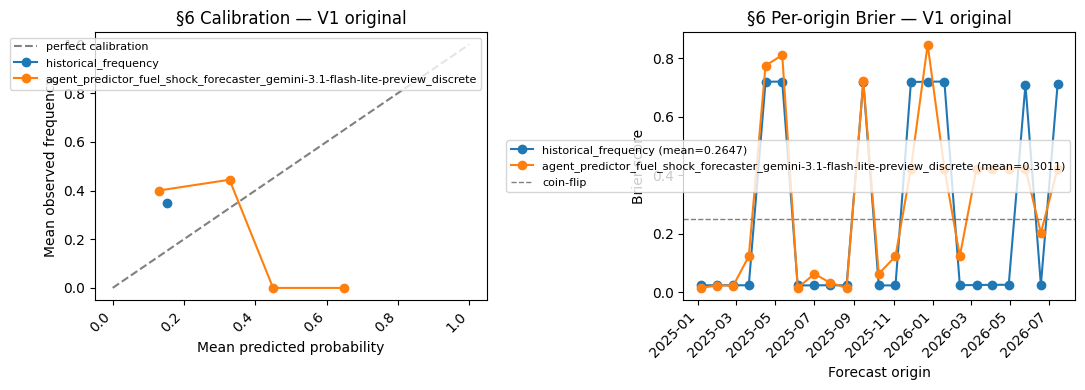

In [16]:
# §6 calibration diagram (V1-original reference)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# — Reliability diagram —
ax = axes[0]
ax.plot([0,1],[0,1], linestyle="--", color="grey", label="perfect calibration")
for pid, result in ref_results.items():
    probs = [pred.payload.probability for pred in result.predictions]
    outs  = [resolved_outcome(pred.forecast_date) for pred in result.predictions]
    paired = [(p,o) for p,o in zip(probs,outs,strict=True) if o is not None]
    if not paired: continue
    ps, os = zip(*paired, strict=True)
    tbl = shock_calibration_table(list(ps), list(os), n_bins=5)
    ax.plot(tbl["mean_predicted"], tbl["mean_observed"], marker="o", label=pid)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Mean observed frequency")
ax.set_title("§6 Calibration — V1 original")
ax.legend(fontsize=8)

# — Per-origin Brier plot —
ax = axes[1]
for pid, result in ref_results.items():
    origins = [pd.Timestamp(pred.as_of) for pred in result.predictions]
    ax.plot(origins, result.scores, marker="o",
            label=f"{pid} (mean={result.mean_score:.4f})")
ax.axhline(0.25, linestyle="--", color="grey", linewidth=1, label="coin-flip")
ax.set_xlabel("Forecast origin")
ax.set_ylabel("Brier score")
ax.set_title("§6 Per-origin Brier — V1 original")
ax.legend(fontsize=8)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
# §6 per-origin detail table (V1-original vs flat baseline)
_ref_baseline_result = ref_results[HistoricalFrequencyPredictor().predictor_id]
_baseline_by_origin = {
    pd.Timestamp(pred.as_of).date(): {
        "baseline_prob":  pred.payload.probability,
        "baseline_brier": round(score, 4),
    }
    for pred, score in zip(
        _ref_baseline_result.predictions, _ref_baseline_result.scores, strict=True
    )
}

_detail_rows = []
for pred, score in zip(_ref_agent_result.predictions, _ref_agent_result.scores, strict=True):
    meta   = pred.metadata or {}
    origin = pd.Timestamp(pred.as_of).date()
    _detail_rows.append({
        "origin":          origin,
        "forecast_date":   pd.Timestamp(pred.forecast_date).date(),
        "outcome":         resolved_outcome(pred.forecast_date),
        "v1orig_prob":     pred.payload.probability,
        "v1orig_brier":    round(score, 4),
        **_baseline_by_origin.get(origin, {"baseline_prob": None, "baseline_brier": None}),
        "direction_bias":  meta.get("direction_bias", "?"),
        "confidence":      meta.get("confidence", "?"),
        "key_signals":     " | ".join(meta.get("key_signals", [])),
    })

ref_detail_df = pd.DataFrame(_detail_rows).sort_values("origin").reset_index(drop=True)
pd.set_option("display.max_colwidth", 120)
ref_detail_df


,origin,forecast_date,outcome,v1orig_prob,v1orig_brier,baseline_prob,baseline_brier,direction_bias,confidence,key_signals
0,2025-01-06,2025-02-04,0.0,0.12,0.0144,0.151653,0.0230,neutral,high,OPEC+ commitment to maintaining production cuts until at least April 2025 | Rising non-OPEC+ oil production offsetti...
1,2025-01-30,2025-02-28,0.0,0.15,0.0225,0.153628,0.0236,neutral,medium,OPEC+ decision to maintain production restraint through April 2025 | Heightened geopolitical risk due to new US sanc...
2,2025-02-25,2025-03-26,0.0,0.15,0.0225,0.153134,0.0235,up,medium,"Unexpected decline in US crude oil inventories (week ended Feb 21, 2025) | Persistent geopolitical tension in the Mi..."
3,2025-03-21,2025-04-21,0.0,0.35,0.1225,0.152616,0.0233,up,medium,Geopolitical tension and shipping-lane risk (Strait of Hormuz) | OPEC+ uncertainty regarding the implementation of t...
4,2025-04-16,2025-05-15,1.0,0.12,0.7744,0.152101,0.7189,neutral,high,OPEC+ gradual return of 2.2 million bpd of production as of April 2025 | EIA downward revision of 2025 crude price f...
5,2025-05-12,2025-06-10,1.0,0.10,0.8100,0.151617,0.7198,down,high,OPEC+ increasing production targets for June 2025 | Bearish global demand outlook exerting pressure on energy prices...
6,2025-06-05,2025-07-04,0.0,0.12,0.0144,0.151137,0.0228,neutral,medium,OPEC+ production increase scheduled for July 2025 | Stabilization of geopolitical risks in the Middle East | Ample g...
7,2025-07-01,2025-07-30,0.0,0.25,0.0625,0.152331,0.0232,up,medium,Geopolitical risk premium centered on the Middle East and Strait of Hormuz | Structural limitations in refining capa...
8,2025-07-25,2025-08-25,0.0,0.18,0.0324,0.153305,0.0235,up,medium,Geopolitical risk premium associated with the Strait of Hormuz | Seasonal peak refinery demand in July/August | Stru...
9,2025-08-20,2025-09-18,0.0,0.12,0.0144,0.152796,0.0233,neutral,medium,OPEC+ gradual production increases (548 kb/d in August 2025) | Global crude oil inventories at a 46-month high as of...


---
## 7. Apples-to-Apples Backtest — V1 vs V2 vs V3 (Full Evaluation)

All three versions run on a **single shared `BacktestSpec`**: same origins, same `SHOCK_EVENT_SERIES_ID` scoring target, same warmup, same `EnhancedFuelPromptBuilder` inputs (WTI + USD covariates). Only the calibration `task_spec` text differs.

**Baselines included:** `HistoricalFrequencyPredictor` (flat unconditional frequency) and `RollingFrequencyPredictor` (trailing 12-month frequency — adapts to regime shifts).

**Statistical validity note:** The 2-year backtest at monthly stride yields ~24 origins. At a typical base rate of 15%, the expected number of shock events is ~3-4. A bootstrap CI on mean Brier will be wide (±0.03 to ±0.05); differences smaller than this are noise. The test is still the correct scientific procedure — it just means we interpret a version as genuinely better only if its CI does not overlap with another's. To detect a Brier improvement of 0.02 with 80% power at α=0.05, you would need ~60 origins (5 years of monthly backtesting), which is the natural next step once this pipeline is validated.

Set `FORCE_REFRESH = True` after editing any prompt spec to recompute from scratch.


In [18]:
FORCE_REFRESH = False

shock_task_backtest = ForecastingTask(
    task_id="fuel_cost_shock_next_month",
    target_series_id=SHOCK_EVENT_SERIES_ID,
    horizons=[SHOCK_HORIZON_DAYS],
    frequency="B",
    payload_type="binary",
    description="Binary cost-shock — apples-to-apples backtest",
)

shared_backtest_spec = BacktestSpec(
    task=shock_task_backtest,
    start=backtest_spec.start,
    end=backtest_spec.end,
    stride=backtest_spec.stride,
    warmup=backtest_spec.warmup,
    description="Shared spec — V1/V2/V3 apples-to-apples",
)

n_candidates = len(shared_backtest_spec.origins())
print(f"Shared spec: {n_candidates} candidate origins | "
      f"start={shared_backtest_spec.start} | end={shared_backtest_spec.end} | "
      f"stride={shared_backtest_spec.stride} | warmup={shared_backtest_spec.warmup}")

all_predictors = [
    (HistoricalFrequencyPredictor(), "baseline_hist"),
    (RollingFrequencyPredictor(),    "baseline_roll"),
    (shock_predictor_v1,             "fuel_shock_v1_enhanced"),
    (shock_predictor_v2,             "fuel_shock_v2"),
    (shock_predictor_v3,             "fuel_shock_v3"),
]

all_results: dict[str, BacktestResult] = {}
for predictor, spec_id in all_predictors:
    print(f"Running {predictor.predictor_id} (spec_id={spec_id}) ...", flush=True)
    result = cached_backtest(
        predictor=predictor,
        spec=shared_backtest_spec,
        spec_id=spec_id,
        data_service=data_service,
        store_dir=PREDICTIONS_DIR,
        force_refresh=FORCE_REFRESH,
    )
    all_results[predictor.predictor_id] = result
    print(f"  mean Brier = {result.mean_score:.4f}  "
          f"({len(result.predictions)} predictions, {result.skipped_origins} skipped)")


Shared spec: 24 candidate origins | start=2025-01-06 00:00:00 | end=2026-08-07 00:00:00 | stride=18 | warmup=252
Running historical_frequency (spec_id=baseline_hist) ...
  mean Brier = 0.2647  (23 predictions, 1 skipped)
Running rolling_freq_12m (spec_id=baseline_roll) ...
  mean Brier = 0.2655  (23 predictions, 1 skipped)
Running agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete (spec_id=fuel_shock_v1_enhanced) ...
  mean Brier = 0.2464  (23 predictions, 1 skipped)
Running agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete (spec_id=fuel_shock_v2) ...
  mean Brier = 0.2576  (23 predictions, 1 skipped)
Running agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete (spec_id=fuel_shock_v3) ...
  mean Brier = 0.2574  (23 predictions, 1 skipped)


In [19]:
# ── Validity check ────────────────────────────────────────────────────────────
hist_baseline_id = HistoricalFrequencyPredictor().predictor_id
roll_baseline_id = RollingFrequencyPredictor.predictor_id

agent_pids = [
    shock_predictor_v1.predictor_id,
    shock_predictor_v2.predictor_id,
    shock_predictor_v3.predictor_id,
]
origin_counts = {pid: len(all_results[pid].predictions) for pid in agent_pids}
unique_counts  = set(origin_counts.values())

if len(unique_counts) > 1:
    print("⚠️  WARNING: versions ran on DIFFERENT origin counts — comparison is INVALID.")
    print("   Set FORCE_REFRESH = True above and re-run.")
    for pid, n in origin_counts.items():
        print(f"   {pid}: {n} origins")
else:
    print(f"✓ All three agent versions ran on {list(unique_counts)[0]} origins — valid comparison.")

# ── Build leaderboard with Brier, log-loss, bootstrap CI, win-rate ────────────
hist_baseline_result = all_results[hist_baseline_id]
hist_baseline_score  = hist_baseline_result.mean_score

VERSION_LABELS = {
    hist_baseline_id:                  "Baseline (hist. freq)",
    roll_baseline_id:                  "Baseline (rolling 12m)",
    shock_predictor_v1.predictor_id:   "V1 Agent (open-ended)",
    shock_predictor_v2.predictor_id:   "V2 Agent (momentum-anchored)",
    shock_predictor_v3.predictor_id:   "V3 Agent (conservative+shrink)",
}

leaderboard_rows = []
for pid, result in all_results.items():
    probs  = [pred.payload.probability for pred in result.predictions]
    outs   = [resolved_outcome(pred.forecast_date) for pred in result.predictions]
    paired = [(p, o) for p, o in zip(probs, outs, strict=True) if o is not None]

    mean_brier       = result.mean_score
    ci_lo, ci_hi     = bootstrap_brier_ci(result.scores)
    ll               = log_loss_score([p for p,_ in paired], [o for _,o in paired]) if paired else float("nan")
    skill            = round(1.0 - mean_brier / hist_baseline_score, 4) if hist_baseline_score > 0 else None

    hist_scores_by_origin = {
        pd.Timestamp(pred.as_of).date(): score
        for pred, score in zip(
            hist_baseline_result.predictions, hist_baseline_result.scores, strict=True
        )
    }
    wins = sum(
        1 for pred, score in zip(result.predictions, result.scores, strict=True)
        if score < hist_scores_by_origin.get(pd.Timestamp(pred.as_of).date(), float("inf"))
    )
    win_rate = wins / len(result.predictions) if result.predictions else float("nan")

    leaderboard_rows.append({
        "predictor":        VERSION_LABELS.get(pid, pid),
        "mean_brier":       round(mean_brier, 4),
        "ci_95_lo":         round(ci_lo, 4),
        "ci_95_hi":         round(ci_hi, 4),
        "log_loss":         round(ll, 4),
        "skill_vs_hist":    skill,
        "win_rate_vs_hist": round(win_rate, 3),
        "n_origins":        len(result.predictions),
    })

leaderboard_df = (
    pd.DataFrame(leaderboard_rows)
    .sort_values("mean_brier")
    .reset_index(drop=True)
)

best_row   = leaderboard_df.iloc[0]
best_label = best_row["predictor"]
best_brier = best_row["mean_brier"]

# ── Simple V1 / V2 / V3 head-to-head (the format you want) ──────────────────
v1_brier    = all_results[shock_predictor_v1.predictor_id].mean_score
v2_brier    = all_results[shock_predictor_v2.predictor_id].mean_score
v3_brier    = all_results[shock_predictor_v3.predictor_id].mean_score
base_brier  = hist_baseline_score

print()
print("=" * 50)
print("BACKTEST BRIER SCORE LEADERBOARD")
print("lower = better | baseline = naive hist. freq.")
print("=" * 50)
print(f"{'Baseline (historical freq)':<35} {base_brier:.4f}")
print(f"{'V1 Agent (open-ended)':<35} {v1_brier:.4f}")
print(f"{'V2 Agent (momentum-anchored)':<35} {v2_brier:.4f}")
print(f"{'V3 Agent (conservative+shrink)':<35} {v3_brier:.4f}")
print()

# Which version won?
best_agent_brier = min(v1_brier, v2_brier, v3_brier)
if best_agent_brier == v1_brier:
    winner = "V1"
elif best_agent_brier == v2_brier:
    winner = "V2"
else:
    winner = "V3"
print(f"► Best agent: {winner}  (Brier = {best_agent_brier:.4f})")

# V1 vs V2
delta_12 = v1_brier - v2_brier
if delta_12 > 0:
    print(f"  V2 is BETTER than V1 by {delta_12:.4f} Brier points")
elif delta_12 < 0:
    print(f"  V2 is WORSE  than V1 by {abs(delta_12):.4f} Brier points")
else:
    print("  V1 and V2 are equal")

# V2 vs V3
delta_23 = v2_brier - v3_brier
if delta_23 > 0:
    print(f"  V3 is BETTER than V2 by {delta_23:.4f} Brier points")
elif delta_23 < 0:
    print(f"  V3 is WORSE  than V2 by {abs(delta_23):.4f} Brier points")
else:
    print("  V2 and V3 are equal")

# ── Full leaderboard (Brier + CI + log-loss + skill + win-rate) ──────────────
print()
print("=" * 90)
print("FULL LEADERBOARD — APPLES-TO-APPLES (all versions, same origins)")
print("Metrics: Brier + 95% bootstrap CI + log-loss + skill vs hist baseline + win-rate")
print("All agent versions use EnhancedFuelPromptBuilder. V3 also mechanically shrunk.")
print("=" * 90)
print(leaderboard_df.to_string(index=False))
print()
print("Interpretation guide:")
print("  skill_vs_hist  > 0  → beats naive flat-frequency baseline")
print("  skill_vs_hist  < 0  → worse than naive baseline")
print("  win_rate_vs_hist    → fraction of origins where agent Brier < baseline Brier")
print("  Overlapping 95% CIs → not statistically distinguishable at this sample size")


✓ All three agent versions ran on 23 origins — valid comparison.

BACKTEST BRIER SCORE LEADERBOARD
lower = better | baseline = naive hist. freq.
Baseline (historical freq)          0.2647
V1 Agent (open-ended)               0.2574
V2 Agent (momentum-anchored)        0.2574
V3 Agent (conservative+shrink)      0.2574

► Best agent: V1  (Brier = 0.2574)
  V1 and V2 are equal
  V2 and V3 are equal

FULL LEADERBOARD — APPLES-TO-APPLES (all versions, same origins)
Metrics: Brier + 95% bootstrap CI + log-loss + skill vs hist baseline + win-rate
All agent versions use EnhancedFuelPromptBuilder. V3 also mechanically shrunk.
                     predictor  mean_brier  ci_95_lo  ci_95_hi  log_loss  skill_vs_hist  win_rate_vs_hist  n_origins
V3 Agent (conservative+shrink)      0.2574    0.1454    0.3794    0.7359         0.0278             0.435         23
         Baseline (hist. freq)      0.2647    0.1439    0.4141    0.7610         0.0000             0.000         23
        Baseline (rolling 

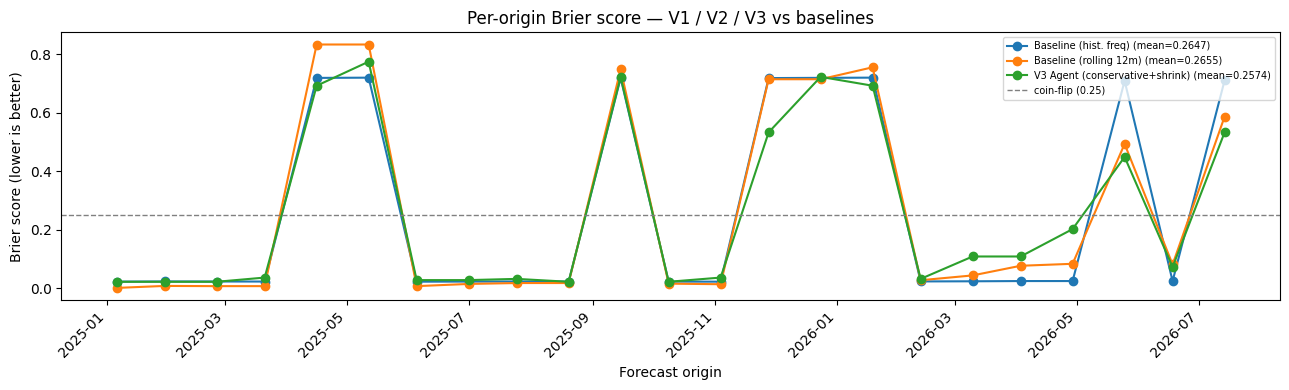

In [20]:
fig, ax = plt.subplots(figsize=(13, 4))
for pid, result in all_results.items():
    origins = [pd.Timestamp(pred.as_of) for pred in result.predictions]
    lbl = f"{VERSION_LABELS.get(pid, pid)} (mean={result.mean_score:.4f})"
    ax.plot(origins, result.scores, marker="o", label=lbl)

ax.axhline(0.25, linestyle="--", color="grey", linewidth=1, label="coin-flip (0.25)")
ax.set_xlabel("Forecast origin")
ax.set_ylabel("Brier score (lower is better)")
ax.set_title("Per-origin Brier score — V1 / V2 / V3 vs baselines")
ax.legend(fontsize=7)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()



Baseline (hist. freq)  (Brier=0.2647, log-loss=0.7610, n=23)
          bin  mean_predicted  mean_observed  n
(-0.001, 0.2]        0.153653       0.347826 23

Baseline (rolling 12m)  (Brier=0.2655, log-loss=0.7750, n=23)
          bin  mean_predicted  mean_observed  n
(-0.001, 0.2]        0.114618       0.352941 17
   (0.2, 0.4]        0.265867       0.333333  6

V3 Agent (conservative+shrink)  (Brier=0.2574, log-loss=0.7359, n=23)
          bin  mean_predicted  mean_observed  n
(-0.001, 0.2]        0.161625         0.3125 16
   (0.2, 0.4]        0.300000         0.5000  6
   (0.4, 0.6]        0.450000         0.0000  1


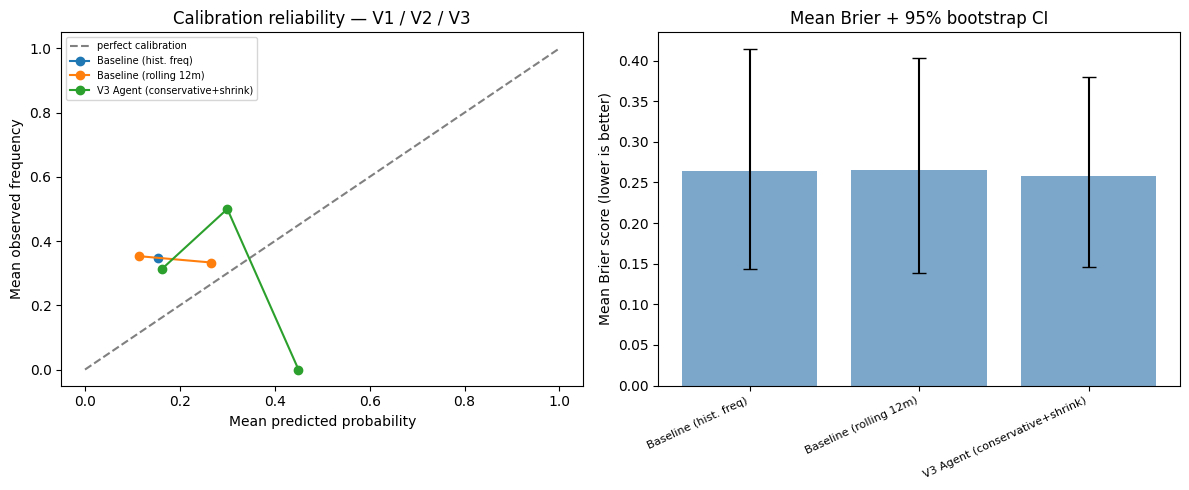

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# — Reliability diagram —
ax = axes[0]
ax.plot([0,1],[0,1], linestyle="--", color="grey", label="perfect calibration")
for pid, result in all_results.items():
    probs = [pred.payload.probability for pred in result.predictions]
    outs  = [resolved_outcome(pred.forecast_date) for pred in result.predictions]
    paired = [(p,o) for p,o in zip(probs,outs,strict=True) if o is not None]
    if not paired: continue
    ps, os = zip(*paired, strict=True)
    tbl = shock_calibration_table(list(ps), list(os), n_bins=5)
    lbl = VERSION_LABELS.get(pid, pid)
    print(f"\n{lbl}  (Brier={result.mean_score:.4f}, log-loss={log_loss_score(list(ps),list(os)):.4f}, n={len(paired)})")
    print(tbl.to_string(index=False))
    ax.plot(tbl["mean_predicted"], tbl["mean_observed"], marker="o", label=lbl)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Mean observed frequency")
ax.set_title("Calibration reliability — V1 / V2 / V3")
ax.legend(fontsize=7)

# — Mean Brier with 95% CI error bars —
ax = axes[1]
labels_ordered = [VERSION_LABELS.get(pid, pid) for pid in all_results]
means   = [all_results[pid].mean_score for pid in all_results]
ci_los  = [bootstrap_brier_ci(all_results[pid].scores)[0] for pid in all_results]
ci_his  = [bootstrap_brier_ci(all_results[pid].scores)[1] for pid in all_results]
yerr_lo = [m - lo for m, lo in zip(means, ci_los)]
yerr_hi = [hi - m  for m, hi in zip(means, ci_his)]
x = range(len(labels_ordered))
ax.bar(x, means, color="steelblue", alpha=0.7)
ax.errorbar(x, means, yerr=[yerr_lo, yerr_hi], fmt="none", color="black", capsize=5)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_ordered, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Mean Brier score (lower is better)")
ax.set_title("Mean Brier + 95% bootstrap CI")

plt.tight_layout()
plt.show()


In [22]:
# Per-origin detail table: all three agent versions + both baselines, side-by-side.
# Shows probability, Brier, direction bias, confidence, key signals, and outcome at every origin.

agent_tags = [
    (shock_predictor_v1.predictor_id, "v1"),
    (shock_predictor_v2.predictor_id, "v2"),
    (shock_predictor_v3.predictor_id, "v3"),
]
baseline_tags = [
    (hist_baseline_id, "hist"),
    (roll_baseline_id, "roll"),
]

by_origin: dict = {}

# Populate baseline columns
for pid, tag in baseline_tags:
    result = all_results[pid]
    for pred, score in zip(result.predictions, result.scores, strict=True):
        origin = pd.Timestamp(pred.as_of).date()
        if origin not in by_origin:
            by_origin[origin] = {
                "origin":        origin,
                "forecast_date": pd.Timestamp(pred.forecast_date).date(),
                "outcome":       resolved_outcome(pred.forecast_date),
            }
        by_origin[origin][f"{tag}_prob"]  = pred.payload.probability
        by_origin[origin][f"{tag}_brier"] = round(score, 4)

# Populate agent columns
for pid, tag in agent_tags:
    result = all_results[pid]
    for pred, score in zip(result.predictions, result.scores, strict=True):
        origin = pd.Timestamp(pred.as_of).date()
        if origin not in by_origin:
            by_origin[origin] = {
                "origin":        origin,
                "forecast_date": pd.Timestamp(pred.forecast_date).date(),
                "outcome":       resolved_outcome(pred.forecast_date),
            }
        meta = pred.metadata or {}
        by_origin[origin].update({
            f"{tag}_prob":        pred.payload.probability,
            f"{tag}_brier":       round(score, 4),
            f"{tag}_log_loss":    round(
                log_loss_score([pred.payload.probability],
                               [by_origin[origin].get("outcome", float("nan"))]), 4
            ),
            f"{tag}_bias":        meta.get("direction_bias", "?"),
            f"{tag}_confidence":  meta.get("confidence", "?"),
            f"{tag}_signals":     " | ".join(meta.get("key_signals", [])),
        })

detail_df = (
    pd.DataFrame(list(by_origin.values()))
    .sort_values("origin")
    .reset_index(drop=True)
)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 40)
detail_df


,origin,forecast_date,outcome,hist_prob,hist_brier,roll_prob,roll_brier,v1_prob,v1_brier,v1_log_loss,v1_bias,v1_confidence,v1_signals,v2_prob,v2_brier,v2_log_loss,v2_bias,v2_confidence,v2_signals,v3_prob,v3_brier,v3_log_loss,v3_bias,v3_confidence,v3_signals
0,2025-01-06,2025-02-04,0.0,0.151653,0.0230,0.0397,0.0016,0.150,0.0225,0.1625,neutral,high,momentum_signals.ret_21d = +5.87% (does not exceed +5% threshold combined wi...,0.150,0.0225,0.1625,neutral,high,momentum_signals.ret_21d = +5.87% (does not exceed +5% threshold combined wi...,0.150,0.0225,0.1625,neutral,high,momentum_signals.ret_21d = +5.87% (does not exceed +5% threshold combined wi...
1,2025-01-30,2025-02-28,0.0,0.153628,0.0236,0.0913,0.0083,0.150,0.0225,0.1625,neutral,high,Ret_21d of +9.32% reflects recent momentum but lacks a supporting supply sho...,0.150,0.0225,0.1625,neutral,high,Ret_21d of +9.32% reflects recent momentum but lacks a supporting supply sho...,0.150,0.0225,0.1625,neutral,high,Ret_21d of +9.32% reflects recent momentum but lacks a supporting supply sho...
2,2025-02-25,2025-03-26,0.0,0.153134,0.0235,0.0873,0.0076,0.150,0.0225,0.1625,neutral,high,Negative 21-day momentum (-1.44%) in jet fuel proxy | Bearish 21-day trend i...,0.150,0.0225,0.1625,neutral,high,Negative 21-day momentum (-1.44%) in jet fuel proxy | Bearish 21-day trend i...,0.150,0.0225,0.1625,neutral,high,Negative 21-day momentum (-1.44%) in jet fuel proxy | Bearish 21-day trend i...
3,2025-03-21,2025-04-21,0.0,0.152616,0.0233,0.0873,0.0076,0.192,0.0369,0.2132,up,medium,Refinery maintenance/outages (PBF Energy facilities/East Coast) | Tight glob...,0.192,0.0369,0.2132,up,medium,Refinery maintenance/outages (PBF Energy facilities/East Coast) | Tight glob...,0.192,0.0369,0.2132,up,medium,Refinery maintenance/outages (PBF Energy facilities/East Coast) | Tight glob...
4,2025-04-16,2025-05-15,1.0,0.152101,0.7189,0.0873,0.8330,0.168,0.6922,1.7838,neutral,medium,OPEC+ initiating gradual reversal of production cuts (bearish for crude) | S...,0.168,0.6922,1.7838,neutral,medium,OPEC+ initiating gradual reversal of production cuts (bearish for crude) | S...,0.168,0.6922,1.7838,neutral,medium,OPEC+ initiating gradual reversal of production cuts (bearish for crude) | S...
5,2025-05-12,2025-06-10,1.0,0.151617,0.7198,0.0873,0.8330,0.120,0.7744,2.1203,down,high,OPEC+ phased production increases effective April 2025 | EIA May 2025 STEO p...,0.120,0.7744,2.1203,down,high,OPEC+ phased production increases effective April 2025 | EIA May 2025 STEO p...,0.120,0.7744,2.1203,down,high,OPEC+ phased production increases effective April 2025 | EIA May 2025 STEO p...
6,2025-06-05,2025-07-04,0.0,0.151137,0.0228,0.0873,0.0076,0.168,0.0282,0.1839,neutral,high,WTI crude +10.0% over 21 days (leading indicator) | OPEC+ gradual unwinding ...,0.168,0.0282,0.1839,neutral,high,WTI crude +10.0% over 21 days (leading indicator) | OPEC+ gradual unwinding ...,0.168,0.0282,0.1839,neutral,high,WTI crude +10.0% over 21 days (leading indicator) | OPEC+ gradual unwinding ...
7,2025-07-01,2025-07-30,0.0,0.152331,0.0232,0.1230,0.0151,0.168,0.0282,0.1839,up,medium,21d momentum at +14.53% indicates strong short-term upward trend | Rising WT...,0.168,0.0282,0.1839,up,medium,21d momentum at +14.53% indicates strong short-term upward trend | Rising WT...,0.168,0.0282,0.1839,up,medium,21d momentum at +14.53% indicates strong short-term upward trend | Rising WT...
8,2025-07-25,2025-08-25,0.0,0.153305,0.0235,0.1349,0.0182,0.180,0.0324,0.1985,up,high,Positive 21d momentum (+5.07%) but below the +5% rule threshold for higher p...,0.180,0.0324,0.1985,up,high,Positive 21d momentum (+5.07%) but below the +5% rule threshold for higher p...,0.180,0.0324,0.1985,up,high,Positive 21d momentum (+5.07%) but below the +5% rule threshold for higher p...
9,2025-08-20,2025-09-18,0.0,0.152796,0.0233,0.1349,0.0182,0.150,0.0225,0.1625,neutral,high,Negative 21d momentum (-10.29%) | Rising OPEC+ production output | Increased...,0.150,0.0225,0.1625,neutral,high,N